# CatBoost — Fake News Classifier

Binary classification of political statements as true (0) or false (1).
Sequence: LogisticRegression → Random Forest → LightGBM. <br>


**NOTE**: The training scripts I used for every training session are in `src\training\`. This is the code of the "latest" version of `catboost.py`. All Markdown cells are from my notes, and generated using copilot. 




LightGBM showed that the `fe_speaker_true_rate` feature dominated gradient boosting — 6X to 8X more weight/gain than any other feature — causing overfitting. CatBoost attacks this with two built-in mechanisms:
- **Ordered boosting**: each sample's target statistic is computed only from samples that came before it in a random permutation, preventing the model from seeing its own label during training.
- **Native categorical handling**: CatBoost internally encodes grouped strings using ordered target statistics, which is strictly better than treating ordinal integers as numeric.

**Architecture:**
- Sentence embeddings (small `all-MiniLM-L6-v2`, 384-dim) for the statement text
- Rich metadata: subject, speaker, party, speaker job, state (with frequency encoding, grouping, interaction keys)
- True-rate features computed fold-safe inside the CV loop (no label leakage)
- Feature `fe_speaker_true_rate` dropped — confirmed to improve holdout F1 even with CatBoost's ordered boosting
- Nested CV: 5-fold outer, 3-fold inner randomized HP search (20 trials per fold)
- Threshold tuning on OOF probabilities, optimising macro F1

**Metric:** Macro F1

## Imports and Project Setup

The `find_project_root` helper walks up the directory tree until it finds the `data/train.csv` file, so this notebook runs correctly from any subdirectory.

In [1]:
from collections import Counter
from datetime import datetime
from pathlib import Path
import sys
from time import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'train.csv').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')

project_root = find_project_root(Path.cwd())
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocessing.one_step import OneStepOptions, preprocess_one_step

print(f'Project root: {project_root}')

_script_start = time()
def _now() -> str:
    return datetime.now().strftime('%H:%M:%S')

c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\CmdrC\Documents\MStanwood\truth-classifier-nlp


## Data Loading

8,950 labeled training samples. Columns: `id`, `label`, `statement`, `subject`, `speaker`, `speaker_job`, `state_info`, `party_affiliation`.

Class distribution: ~35% true (0), ~65% false (1). This imbalance is handled via class weights `{0: 1.42, 1: 0.77}` — computed as `n_samples / (2 * n_class_i)`.

In [2]:
df = pd.read_csv(project_root / 'data' / 'train.csv')
print(f'Shape: {df.shape}')
print(f"\nLabel distribution:\n{df['label'].value_counts(normalize=True).round(4)}")
df.head()

Shape: (8950, 8)

Label distribution:
label
1    0.6475
0    0.3525
Name: proportion, dtype: float64


,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation
0,81f884c64a7,1,China is in the South China Sea and (building)...,"china,foreign-policy,military",donald-trump,President-Elect,New York,republican
1,30c2723a188,0,With the resources it takes to execute just ov...,health-care,chris-dodd,U.S. senator,Connecticut,democrat
2,6936b216e5d,0,The (Wisconsin) governor has proposed tax give...,"corporations,pundits,taxes,abc-news-week",donna-brazile,Political commentator,"Washington, D.C.",democrat
3,b5cd9195738,1,Says her representation of an ex-boyfriend who...,"candidates-biography,children,ethics,families,...",rebecca-bradley,NaN,NaN,none
4,84f8dac7737,0,At protests in Wisconsin against proposed coll...,"health-care,labor,state-budget",republican-party-wisconsin,NaN,Wisconsin,republican


## Preprocessing Configuration

All preprocessing is controlled through `OneStepOptions`. Each module is configured independently below.

Key decisions for CatBoost (vs linear model):
- **No scaling** (`*_scale = 'none'`): trees are invariant to monotone transforms; scaling adds no value and wastes time.
- **No stemming/lemmatization**: these help linear models but trees gain nothing and may lose token distinctions.
- **Stopword removal = OFF**: sentence embeddings need natural language — removing function words corrupts the input.
- **NER features ON**: `en_core_web_sm` adds entity counts (PERSON, ORG, GPE, DATE) which are useful for political fact-checking.
- **Embeddings** (small `all-MiniLM-L6-v2`, 384-dim): dense semantic vectors, stateless at inference time.

In [3]:
# --- Label & ID ---
label_option      = 'skip'   # keep label column for training
label_source_col  = 'label'
id_option         = 'drop'

# --- Subject ---
subject_source_col             = 'subject'
subject_keep_original          = False
subject_clean_text             = True
subject_normalize_separators   = True
subject_split_topics           = True
subject_primary_strategy       = 'most_frequent'  # most stable across CV splits
subject_rare_threshold         = 10
subject_rare_label             = 'other'
subject_max_topics_for_primary = None
subject_multi_topic_label      = 'multi-topic'
subject_add_primary            = True
subject_add_topic_count        = True
subject_add_multiple_topics_flag = True
subject_add_topic_list         = False
subject_add_length_features    = True
subject_add_grouped_primary    = True
subject_group_rare             = True
subject_add_subject_frequency  = True
subject_add_subject_is_rare    = True
subject_add_subject_primary_true_rate = False  # computed fold-safe in CV loop
subject_label_col              = None
subject_scale                  = 'none'
subject_verbose                = False

In [4]:
# --- Statement ---
statement_source_col            = 'statement'
statement_original_output_col   = 'statement_original'
statement_output_col            = 'statement_clean'
statement_keep_original         = False
statement_lower                 = True
statement_remove_html           = True
statement_remove_urls           = True
statement_replace_numbers       = False
statement_number_token          = '<NUM>'
statement_stopword_removal      = False   # OFF: embeddings need natural language
statement_keep_negations        = True
statement_remove_punctuation    = False
statement_stemmer               = 'none'  # OFF: trees gain nothing from stemming
statement_lemmatizer            = 'none'
statement_repair_polluted_statements = True
statement_add_rare_token_features = True
statement_rare_token_threshold  = 1
statement_token_freqs           = None
statement_add_spelling_errors   = True
statement_add_lexical_features  = True
statement_add_pollution_features = True
statement_add_ner_features      = True    # PERSON, ORG, GPE, DATE counts
statement_ner_model             = 'en_core_web_sm'
statement_vectorizer_type       = 'embeddings'
statement_vectorizer_max_features = 500
statement_vectorizer_min_df     = 2
statement_vectorizer_max_df     = 0.7
statement_embedding_model       = 'all-MiniLM-L6-v2'  # 384-dim
statement_fitted_vectorizer     = None
statement_scale                 = 'none'
statement_verbose               = False

In [5]:
# --- Speaker ---
speaker_source_col            = 'speaker'
speaker_keep_original         = False
speaker_clean_text            = True
speaker_normalize_separators  = True
speaker_group_rare            = True
speaker_rare_threshold        = 5
speaker_rare_label            = 'other'
speaker_add_frequency         = True
speaker_add_is_rare           = True
speaker_add_grouped_speaker   = True
speaker_add_length_features   = True
speaker_add_title_flag        = True
speaker_add_comma_flag        = True
speaker_add_period_flag       = True
speaker_add_token_count       = False
speaker_add_speaker_primary_true_rate = False
speaker_label_col             = None
speaker_scale                 = 'none'
speaker_verbose               = False

# --- Speaker job ---
speaker_job_source_col           = 'speaker_job'
speaker_job_keep_original        = False
speaker_job_clean_text           = True
speaker_job_normalize_separators = True
speaker_job_group_rare           = True
speaker_job_rare_threshold       = 5
speaker_job_rare_label           = 'other'
speaker_job_add_frequency        = True
speaker_job_add_is_rare          = True
speaker_job_add_grouped_job      = True
speaker_job_add_length_features  = True
speaker_job_add_title_flag       = True
speaker_job_add_comma_flag       = True
speaker_job_add_slash_flag       = True
speaker_job_add_ampersand_flag   = True
speaker_job_add_token_count      = False
speaker_job_add_job_primary_true_rate = False
speaker_job_job_label_col        = None
speaker_job_scale                = 'none'
speaker_job_verbose              = False

# --- Party affiliation ---
party_affiliation_source_col       = 'party_affiliation'
party_affiliation_keep_original    = False
party_affiliation_clean_text       = True
party_affiliation_group_rare       = True
party_affiliation_rare_threshold   = 5
party_affiliation_rare_label       = 'other'
party_affiliation_add_frequency    = True
party_affiliation_add_is_rare      = True
party_affiliation_add_grouped_party = True
party_affiliation_add_length_features = True
party_affiliation_add_token_count  = True
party_affiliation_add_is_major_party = True
party_affiliation_add_is_institutional = True
party_affiliation_add_slash_flag   = True
party_affiliation_add_ampersand_flag = True
party_affiliation_add_comma_flag   = False
party_affiliation_add_parentheses_flag = True
party_affiliation_add_party_primary_true_rate = False
party_affiliation_party_label_col  = None
party_affiliation_scale            = 'none'
party_affiliation_verbose          = False

# --- State info ---
state_source_col       = 'state_info'
state_drop             = False
state_keep_original    = False
state_clean_text       = True
state_normalize_state  = True
state_group_rare       = True
state_rare_threshold   = 5
state_rare_label       = 'other'
state_add_is_us_state  = True
state_add_frequency    = True
state_add_is_rare      = True
state_add_grouped_state = True
state_add_has_us_words = True
state_add_us_region    = True
state_add_length_features = False
state_add_token_count  = True
state_scale            = 'none'
state_verbose          = False

In [6]:
# --- Feature Engineering ---
# Three families:
#   1. Interaction keys — joint categorical strings for direct tree splitting
#      ("does speaker X lie on topic Y?") — no leakage risk
#   2. Aggregate stats — true-rate features computed fold-safe inside CV loop
#   3. Text-style — linguistic deception signals

fe_statement_col          = 'statement_clean'
fe_statement_original_col = 'statement_original'
fe_speaker_col            = 'speaker_clean'
fe_subject_col            = 'subject_clean'
fe_party_col              = 'party_affiliation_clean'
fe_speaker_job_col        = 'speaker_job_clean'
fe_state_col              = 'state_info_clean'
fe_label_col              = None  # true-rates computed in CV loop, not here

# 1. Interaction features
fe_add_speaker_subject            = True
fe_add_speaker_party              = True
fe_add_subject_party              = True
fe_add_speaker_job_subject        = True
fe_add_state_party                = True
fe_add_speaker_statement_len_bucket = True
fe_statement_len_bins             = (50, 150)

# 2. True-rate aggregates — False here, computed fold-safe in CV loop
fe_add_speaker_true_rate          = False
fe_add_subject_true_rate          = False
fe_add_party_true_rate            = False

# 2b. Non-leaking aggregates
fe_add_speaker_avg_statement_len  = True
fe_add_subject_avg_statement_len  = True
fe_add_speaker_avg_punctuation    = True
fe_add_speaker_avg_number_ratio   = True

# 3. Text-style features
fe_add_negation_count    = True  # fake claims use more negations
fe_add_hedge_count       = True  # hedging = vague/unverifiable claims
fe_add_absolutist_count  = True  # absolutist language correlates with exaggeration
fe_add_numeral_count     = True  # specific numbers are a strong PolitiFact signal
fe_add_proper_noun_count = False  # statement_original dropped; can't use casing heuristic
fe_add_readability       = True
fe_add_sentiment         = True

fe_scale    = 'none'
fe_verbose  = False

In [7]:
options = OneStepOptions(
    label_option=label_option, label_source_col=label_source_col, id_option=id_option,
    subject_source_col=subject_source_col, subject_keep_original=subject_keep_original,
    subject_clean_text=subject_clean_text, subject_normalize_separators=subject_normalize_separators,
    subject_split_topics=subject_split_topics, subject_primary_strategy=subject_primary_strategy,
    subject_max_topics_for_primary=subject_max_topics_for_primary,
    subject_multi_topic_label=subject_multi_topic_label,
    subject_add_primary=subject_add_primary, subject_add_topic_count=subject_add_topic_count,
    subject_add_multiple_topics_flag=subject_add_multiple_topics_flag,
    subject_add_topic_list=subject_add_topic_list, subject_add_length_features=subject_add_length_features,
    subject_add_grouped_primary=subject_add_grouped_primary, subject_group_rare=subject_group_rare,
    subject_rare_threshold=subject_rare_threshold, subject_rare_label=subject_rare_label,
    subject_add_subject_frequency=subject_add_subject_frequency,
    subject_add_subject_is_rare=subject_add_subject_is_rare,
    subject_add_subject_primary_true_rate=subject_add_subject_primary_true_rate,
    subject_label_col=subject_label_col, subject_scale=subject_scale, subject_verbose=subject_verbose,
    statement_source_col=statement_source_col, statement_original_output_col=statement_original_output_col,
    statement_output_col=statement_output_col, statement_keep_original=statement_keep_original,
    statement_lower=statement_lower, statement_remove_html=statement_remove_html,
    statement_remove_urls=statement_remove_urls, statement_replace_numbers=statement_replace_numbers,
    statement_number_token=statement_number_token, statement_stopword_removal=statement_stopword_removal,
    statement_keep_negations=statement_keep_negations, statement_stemmer=statement_stemmer,
    statement_lemmatizer=statement_lemmatizer, statement_remove_punctuation=statement_remove_punctuation,
    statement_repair_polluted_statements=statement_repair_polluted_statements,
    statement_add_rare_token_features=statement_add_rare_token_features,
    statement_rare_token_threshold=statement_rare_token_threshold,
    statement_token_freqs=statement_token_freqs, statement_add_spelling_errors=statement_add_spelling_errors,
    statement_add_lexical_features=statement_add_lexical_features,
    statement_add_pollution_features=statement_add_pollution_features,
    statement_add_ner_features=statement_add_ner_features, statement_ner_model=statement_ner_model,
    statement_vectorizer_type=statement_vectorizer_type,
    statement_vectorizer_max_features=statement_vectorizer_max_features,
    statement_vectorizer_min_df=statement_vectorizer_min_df,
    statement_vectorizer_max_df=statement_vectorizer_max_df,
    statement_embedding_model=statement_embedding_model,
    statement_fitted_vectorizer=statement_fitted_vectorizer,
    statement_scale=statement_scale, statement_verbose=statement_verbose,
    speaker_source_col=speaker_source_col, speaker_keep_original=speaker_keep_original,
    speaker_clean_text=speaker_clean_text, speaker_normalize_separators=speaker_normalize_separators,
    speaker_group_rare=speaker_group_rare, speaker_rare_threshold=speaker_rare_threshold,
    speaker_rare_label=speaker_rare_label, speaker_add_frequency=speaker_add_frequency,
    speaker_add_is_rare=speaker_add_is_rare, speaker_add_grouped_speaker=speaker_add_grouped_speaker,
    speaker_add_length_features=speaker_add_length_features, speaker_add_title_flag=speaker_add_title_flag,
    speaker_add_comma_flag=speaker_add_comma_flag, speaker_add_period_flag=speaker_add_period_flag,
    speaker_add_token_count=speaker_add_token_count,
    speaker_add_speaker_primary_true_rate=speaker_add_speaker_primary_true_rate,
    speaker_label_col=speaker_label_col, speaker_scale=speaker_scale, speaker_verbose=speaker_verbose,
    speaker_job_source_col=speaker_job_source_col, speaker_job_keep_original=speaker_job_keep_original,
    speaker_job_clean_text=speaker_job_clean_text,
    speaker_job_normalize_separators=speaker_job_normalize_separators,
    speaker_job_group_rare=speaker_job_group_rare, speaker_job_rare_threshold=speaker_job_rare_threshold,
    speaker_job_rare_label=speaker_job_rare_label, speaker_job_add_frequency=speaker_job_add_frequency,
    speaker_job_add_is_rare=speaker_job_add_is_rare, speaker_job_add_grouped_job=speaker_job_add_grouped_job,
    speaker_job_add_length_features=speaker_job_add_length_features,
    speaker_job_add_title_flag=speaker_job_add_title_flag,
    speaker_job_add_comma_flag=speaker_job_add_comma_flag, speaker_job_add_slash_flag=speaker_job_add_slash_flag,
    speaker_job_add_ampersand_flag=speaker_job_add_ampersand_flag,
    speaker_job_add_token_count=speaker_job_add_token_count,
    speaker_job_add_job_primary_true_rate=speaker_job_add_job_primary_true_rate,
    speaker_job_job_label_col=speaker_job_job_label_col,
    speaker_job_scale=speaker_job_scale, speaker_job_verbose=speaker_job_verbose,
    party_affiliation_source_col=party_affiliation_source_col,
    party_affiliation_keep_original=party_affiliation_keep_original,
    party_affiliation_clean_text=party_affiliation_clean_text,
    party_affiliation_group_rare=party_affiliation_group_rare,
    party_affiliation_rare_threshold=party_affiliation_rare_threshold,
    party_affiliation_rare_label=party_affiliation_rare_label,
    party_affiliation_add_frequency=party_affiliation_add_frequency,
    party_affiliation_add_is_rare=party_affiliation_add_is_rare,
    party_affiliation_add_grouped_party=party_affiliation_add_grouped_party,
    party_affiliation_add_length_features=party_affiliation_add_length_features,
    party_affiliation_add_token_count=party_affiliation_add_token_count,
    party_affiliation_add_is_major_party=party_affiliation_add_is_major_party,
    party_affiliation_add_is_institutional=party_affiliation_add_is_institutional,
    party_affiliation_add_slash_flag=party_affiliation_add_slash_flag,
    party_affiliation_add_ampersand_flag=party_affiliation_add_ampersand_flag,
    party_affiliation_add_comma_flag=party_affiliation_add_comma_flag,
    party_affiliation_add_parentheses_flag=party_affiliation_add_parentheses_flag,
    party_affiliation_add_party_primary_true_rate=party_affiliation_add_party_primary_true_rate,
    party_affiliation_party_label_col=party_affiliation_party_label_col,
    party_affiliation_scale=party_affiliation_scale, party_affiliation_verbose=party_affiliation_verbose,
    state_source_col=state_source_col, state_drop=state_drop, state_keep_original=state_keep_original,
    state_clean_text=state_clean_text, state_normalize_state=state_normalize_state,
    state_group_rare=state_group_rare, state_rare_threshold=state_rare_threshold,
    state_rare_label=state_rare_label, state_add_is_us_state=state_add_is_us_state,
    state_add_frequency=state_add_frequency, state_add_is_rare=state_add_is_rare,
    state_add_grouped_state=state_add_grouped_state, state_add_length_features=state_add_length_features,
    state_add_token_count=state_add_token_count, state_add_has_us_words=state_add_has_us_words,
    state_add_us_region=state_add_us_region, state_scale=state_scale, state_verbose=state_verbose,
    fe_statement_col=fe_statement_col, fe_statement_original_col=fe_statement_original_col,
    fe_speaker_col=fe_speaker_col, fe_subject_col=fe_subject_col, fe_party_col=fe_party_col,
    fe_speaker_job_col=fe_speaker_job_col, fe_state_col=fe_state_col, fe_label_col=fe_label_col,
    fe_add_speaker_subject=fe_add_speaker_subject, fe_add_speaker_party=fe_add_speaker_party,
    fe_add_subject_party=fe_add_subject_party, fe_add_speaker_job_subject=fe_add_speaker_job_subject,
    fe_add_state_party=fe_add_state_party,
    fe_add_speaker_statement_len_bucket=fe_add_speaker_statement_len_bucket,
    fe_statement_len_bins=fe_statement_len_bins,
    fe_add_speaker_true_rate=fe_add_speaker_true_rate, fe_add_subject_true_rate=fe_add_subject_true_rate,
    fe_add_party_true_rate=fe_add_party_true_rate,
    fe_add_speaker_avg_statement_len=fe_add_speaker_avg_statement_len,
    fe_add_subject_avg_statement_len=fe_add_subject_avg_statement_len,
    fe_add_speaker_avg_punctuation=fe_add_speaker_avg_punctuation,
    fe_add_speaker_avg_number_ratio=fe_add_speaker_avg_number_ratio,
    fe_add_negation_count=fe_add_negation_count, fe_add_hedge_count=fe_add_hedge_count,
    fe_add_absolutist_count=fe_add_absolutist_count, fe_add_numeral_count=fe_add_numeral_count,
    fe_add_proper_noun_count=fe_add_proper_noun_count, fe_add_readability=fe_add_readability,
    fe_add_sentiment=fe_add_sentiment, fe_scale=fe_scale, fe_verbose=fe_verbose,
)

## Run Preprocessing

This is the slowest step (~5–10 min) because it encodes sentence embeddings for all 8,950 rows. The result is a fully numeric feature table (plus string categoricals that will be OrdinalEncoded next).

In [8]:
print(f'[{_now()}] Running preprocessing...')
_t0 = time()
df_processed = preprocess_one_step(df, options=options)
print(f'Done in {time()-_t0:.1f}s  |  Rows: {len(df_processed):,}  |  Columns: {df_processed.shape[1]}')
df_processed.dtypes.value_counts()

[20:30:38] Running preprocessing...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18671.16it/s]


Done in 49.5s  |  Rows: 8,950  |  Columns: 474


float32    384
int64       55
str         20
float64     14
bool         1
Name: count, dtype: int64

## Categorical Encoding

After preprocessing, string columns fall into two groups:
- **Text strings** (`*_clean`, `*_original`, raw source columns): dropped — not useful as tree features.
- **Grouped categories / interaction keys** (`speaker_grouped`, `fe_speaker_subject`, `state_info_us_region`, etc.): OrdinalEncoded to integers.

OrdinalEncoder assigns one integer per category; trees split on thresholds and can learn "speaker 42 lies more" without a binary indicator per speaker. Interaction keys like `speaker×subject` have hundreds of unique values. OneHotEncoding would create more columns than rows. 

**CatBoost advantage:** We pass the categorical column indices to CatBoostClassifier via `cat_features`. CatBoost then applies its internal ordered target statistics on top of the integer codes — effectively re-encoding categoricals in a leakage-free way during each boosting iteration. Works way better than what LGBM does (treats ordinal integers as numeric).

In [9]:
_all_obj_cols = df_processed.select_dtypes(include='object').columns.tolist()
_source_cols = {
    statement_source_col, speaker_source_col, subject_source_col,
    speaker_job_source_col, party_affiliation_source_col, state_source_col,
}
_text_cols = (
    {c for c in _all_obj_cols if c.endswith(('_clean', '_original'))}
    | (_source_cols & set(_all_obj_cols))
)
_cat_cols = [c for c in _all_obj_cols if c not in _text_cols and c != label_source_col]

print(f'Text columns dropped     : {sorted(_text_cols)}')
print(f'Categorical cols encoded : {_cat_cols}')

ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int)
_cat_encoded = pd.DataFrame(
    ordinal_enc.fit_transform(df_processed[_cat_cols]),
    columns=_cat_cols,
    index=df_processed.index,
)

df_features = pd.concat(
    [df_processed.select_dtypes(exclude='object'), _cat_encoded],
    axis=1,
)

_cat_feature_names = [c for c in _cat_encoded.columns if c != label_source_col]
print(f'\nTotal features after encoding: {df_features.shape[1]}')

Text columns dropped     : ['party_affiliation_clean', 'speaker_clean', 'speaker_job_clean', 'state_info_clean', 'statement', 'statement_clean', 'subject_clean']
Categorical cols encoded : ['subject_primary', 'subject_primary_grouped', 'speaker_grouped', 'speaker_job_grouped', 'party_affiliation_grouped', 'state_info_grouped', 'state_info_us_region', 'fe_speaker_subject', 'fe_speaker_party', 'fe_subject_party', 'fe_speaker_job_subject', 'fe_state_party', 'fe_speaker_len_bucket']

Total features after encoding: 467


C:\Users\CmdrC\AppData\Local\Temp\ipykernel_17456\107263632.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  _all_obj_cols = df_processed.select_dtypes(include='object').columns.tolist()


## Feature Matrix

Inspect the feature composition before splitting: how many are embedding dimensions vs. encoded categoricals vs. other numeric features.

In [10]:
X = df_features.drop(columns=[label_source_col])
y = df_processed[label_source_col]

vec_cols   = [c for c in X.columns if '_vec_' in c or c.startswith('vec_')]
cat_cols_X = [c for c in X.columns if c in _cat_cols]
other_cols = [c for c in X.columns if c not in vec_cols and c not in cat_cols_X]

print(f'Embedding dimensions : {len(vec_cols)}')
print(f'Encoded categoricals : {len(cat_cols_X)}  →  {cat_cols_X}')
print(f'Other numeric        : {len(other_cols)}  →  {other_cols}')
print(f'Total features       : {X.shape[1]}')
print(f'\nTarget distribution:\n{y.value_counts(normalize=True).round(4)}')

Embedding dimensions : 384
Encoded categoricals : 13  →  ['subject_primary', 'subject_primary_grouped', 'speaker_grouped', 'speaker_job_grouped', 'party_affiliation_grouped', 'state_info_grouped', 'state_info_us_region', 'fe_speaker_subject', 'fe_speaker_party', 'fe_subject_party', 'fe_speaker_job_subject', 'fe_state_party', 'fe_speaker_len_bucket']
Other numeric        : 69  →  ['subject_topic_count', 'subject_has_multiple_topics', 'subject_length', 'subject_token_count', 'subject_frequency', 'subject_is_rare', 'statement_row_spillover_flag', 'statement_tab_count', 'statement_newline_count', 'statement_original_char_len', 'statement_original_word_count', 'statement_upper_ratio', 'statement_exclamation_count', 'statement_question_count', 'statement_clean_digit_ratio', 'statement_clean_rare_token_count', 'statement_clean_avg_token_freq', 'statement_clean_spelling_err_count', 'statement_original_total_entities', 'statement_original_PERSON', 'statement_original_ORG', 'statement_original_G

## Train / Holdout Split

20% stratified holdout — held out until final evaluation. The same `random_state=42` is used across all scripts so the holdout set is identical across experiments.

In [11]:
X_trainval, X_holdout, y_trainval, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Train/val : {X_trainval.shape[0]:,}  |  Holdout : {X_holdout.shape[0]:,}  |  CV folds : {skf.get_n_splits()}')

Train/val : 7,160  |  Holdout : 1,790  |  CV folds : 5


## Model Configuration

Using (`drop_speaker_true_rate=True`): the CatBoost initial run showed that even with ordered boosting, `fe_speaker_true_rate` still dominated at 8.76× the gain of the next feature. Dropping it lets subject/party/job true-rates and the embedding dimensions claim a fairer share.

**HP search space:**
| Parameter | Range | What it controls |
|---|---|---|
| `iterations` | 300, 500, 800 | Number of trees |
| `learning_rate` | 0.03–0.2 | Shrinkage |
| `depth` | 4, 6, 8, 10 | Symmetric tree depth (2^depth leaf patterns) |
| `l2_leaf_reg` | 1, 3, 5, 10 | L2 penalty on leaf values |
| `border_count` | 32, 64, 128 | Histogram bins per feature |
| `bagging_temperature` | 0.0, 0.5, 1.0 | Bayesian bootstrap randomness |

In [12]:
CLASS_WEIGHTS = [1.42, 0.77]  # balanced: n / (2 * n_class_i)
THRESHOLD     = 0.5

enable_threshold_tuning = True
overwrite_threshold     = True
THRESHOLD_METRIC        = 'macro_f1'

enable_hp_search = True
N_ITER_SEARCH    = 20
N_CV_INNER       = 3

param_dist = {
    'iterations':          [300, 500, 800],
    'learning_rate':       [0.03, 0.05, 0.1, 0.2],
    'depth':               [4, 6, 8, 10],
    'l2_leaf_reg':         [1, 3, 5, 10],
    'border_count':        [32, 64, 128],
    'bagging_temperature': [0.0, 0.5, 1.0],
}

enable_true_rate_features = True
drop_speaker_true_rate    = True  # Option B
true_rate_fallback        = 0.5

## True-Rate Feature Setup

True-rate features are computed only on the training split of each fold, then mapped to the validation split. If computed on the full dataset, the model sees each sample's own label during training — a form of target leakage that inflates CV scores but collapses on holdout.

The placeholder `true_rate_fallback = 0.5` is written to `X_trainval` and `X_holdout` now; the real per-fold means overwrite it inside the CV loop.

In [13]:
_tr_group_cols: dict = {}
if enable_true_rate_features:
    _candidates = {
        'fe_subject_true_rate':     ['subject_primary_grouped', 'subject_primary', 'subject_clean'],
        'fe_party_true_rate':       ['party_affiliation_grouped', 'party_affiliation_clean'],
        'fe_speaker_job_true_rate': ['speaker_job_grouped', 'speaker_job_clean'],
    }
    if not drop_speaker_true_rate:
        _candidates['fe_speaker_true_rate'] = ['speaker_grouped', 'speaker_clean']

    for _feat, _src_cols in _candidates.items():
        for _col in _src_cols:
            if _col in df_processed.columns:
                _tr_group_cols[_feat] = _col
                break

    X_trainval = X_trainval.copy()
    X_holdout  = X_holdout.copy()
    for _feat in _tr_group_cols:
        X_trainval[_feat] = true_rate_fallback
        X_holdout[_feat]  = true_rate_fallback

    _grp_trainval = pd.DataFrame(
        {col: df_processed[col].loc[X_trainval.index].values for col in _tr_group_cols.values()}
    )
    _grp_trainval['_label'] = y_trainval.values

    _grp_holdout = pd.DataFrame(
        {col: df_processed[col].loc[X_holdout.index].values for col in _tr_group_cols.values()}
    )

    print(f'True-rate features : {list(_tr_group_cols.keys())}')
    print(f'Source columns     : {list(_tr_group_cols.values())}')

True-rate features : ['fe_subject_true_rate', 'fe_party_true_rate', 'fe_speaker_job_true_rate']
Source columns     : ['subject_primary_grouped', 'party_affiliation_grouped', 'speaker_job_grouped']


## Cross-Validation

**Nested CV design:**
- **Outer loop (5 folds):** collects OOF probabilities for threshold tuning and unbiased metric estimates.
- **Inner loop (3-fold manual random search, 20 trials):** finds the best HP set per fold without leaking from the validation fold. We implement this manually instead of using `RandomizedSearchCV` because `sklearn.clone()` breaks with CatBoost's internal parameter normalisation.

Inside each fold, true-rate features are recomputed on the fold training split only, then mapped to the fold validation split — ensuring no label leakage.

In [14]:
print(f'[{_now()}] Starting cross-validation...')
_cv_start = time()
cv_fold_metrics = []
oof_proba = np.zeros(len(X_trainval))
oof_true  = np.zeros(len(X_trainval), dtype=int)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    _fold_t = time()

    X_fold_train = X_trainval.iloc[train_idx].copy()
    X_fold_val   = X_trainval.iloc[val_idx].copy()
    y_fold_train = y_trainval.iloc[train_idx]
    y_fold_val   = y_trainval.iloc[val_idx]

    # True-rate features — computed on fold training split only
    if enable_true_rate_features and _tr_group_cols:
        _grp_tr = _grp_trainval.iloc[train_idx]
        _grp_vl = _grp_trainval.iloc[val_idx]
        for _feat, _src_col in _tr_group_cols.items():
            _rate_map = _grp_tr.groupby(_src_col)['_label'].mean()
            X_fold_train[_feat] = _grp_tr[_src_col].map(_rate_map).fillna(true_rate_fallback).values
            X_fold_val[_feat]   = _grp_vl[_src_col].map(_rate_map).fillna(true_rate_fallback).values

    _cat_indices = [X_fold_train.columns.get_loc(c) for c in _cat_feature_names
                    if c in X_fold_train.columns]

    if enable_hp_search:
        _inner_cv  = StratifiedKFold(n_splits=N_CV_INNER, shuffle=True, random_state=42)
        _rng       = np.random.RandomState(42)
        _best_inner_score = -np.inf
        fold_best_params  = {}

        def _cast(v):
            if isinstance(v, np.integer): return int(v)
            if isinstance(v, np.floating): return float(v)
            return v

        for _trial in range(N_ITER_SEARCH):
            _trial_params = {k: _rng.choice(v) for k, v in param_dist.items()}
            _trial_scores = []
            for _itr_idx, _ival_idx in _inner_cv.split(X_fold_train, y_fold_train):
                _Xi_tr = X_fold_train.iloc[_itr_idx]
                _Xi_vl = X_fold_train.iloc[_ival_idx]
                _yi_tr = y_fold_train.iloc[_itr_idx]
                _yi_vl = y_fold_train.iloc[_ival_idx]
                _inner_cat = [_Xi_tr.columns.get_loc(c) for c in _cat_feature_names if c in _Xi_tr.columns]
                _m = CatBoostClassifier(
                    **{k: _cast(v) for k, v in _trial_params.items()},
                    cat_features=_inner_cat, auto_class_weights='Balanced',
                    thread_count=-1, random_seed=42, verbose=0,
                )
                _m.fit(_Xi_tr, _yi_tr)
                _trial_scores.append(f1_score(_yi_vl, _m.predict(_Xi_vl), average='macro', zero_division=0))

            _mean = float(np.mean(_trial_scores))
            if _mean > _best_inner_score:
                _best_inner_score = _mean
                fold_best_params  = {k: _cast(v) for k, v in _trial_params.items()}

        fold_model = CatBoostClassifier(
            **fold_best_params, cat_features=_cat_indices,
            auto_class_weights='Balanced', thread_count=-1, random_seed=42, verbose=0,
        )
        fold_model.fit(X_fold_train, y_fold_train)
    else:
        fold_best_params = {}
        fold_model = CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=3,
            cat_features=_cat_indices, auto_class_weights='Balanced',
            thread_count=-1, random_seed=42, verbose=0,
        )
        fold_model.fit(X_fold_train, y_fold_train)

    y_fold_pred  = fold_model.predict(X_fold_val)
    y_fold_proba = fold_model.predict_proba(X_fold_val)[:, 1]
    oof_proba[val_idx] = y_fold_proba
    oof_true[val_idx]  = y_fold_val.values

    fold_metrics = {
        'fold':         fold_idx,
        'roc_auc':      roc_auc_score(y_fold_val, y_fold_proba),
        'macro_f1':     f1_score(y_fold_val, y_fold_pred, average='macro', zero_division=0),
        'mcc':          matthews_corrcoef(y_fold_val, y_fold_pred),
        'balanced_acc': balanced_accuracy_score(y_fold_val, y_fold_pred),
        'best_params':  fold_best_params,
    }
    cv_fold_metrics.append(fold_metrics)
    print(
        f'  Fold {fold_idx} | ROC-AUC={fold_metrics["roc_auc"]:.4f}  '
        f'Macro-F1={fold_metrics["macro_f1"]:.4f}  '
        f'MCC={fold_metrics["mcc"]:.4f}  '
        f'({time()-_fold_t:.1f}s)'
    )
    if enable_hp_search:
        print(f'    Best HP: {fold_best_params}  (inner macro_f1={_best_inner_score:.4f})')

print(f'\nTotal CV time: {time()-_cv_start:.1f}s')

[20:31:28] Starting cross-validation...
  Fold 1 | ROC-AUC=0.6583  Macro-F1=0.6065  MCC=0.2137  (1080.2s)
    Best HP: {'iterations': 500, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 1, 'border_count': 64, 'bagging_temperature': 1.0}  (inner macro_f1=0.6238)
  Fold 2 | ROC-AUC=0.6809  Macro-F1=0.6288  MCC=0.2653  (1197.4s)
    Best HP: {'iterations': 300, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5, 'border_count': 32, 'bagging_temperature': 0.0}  (inner macro_f1=0.6182)
  Fold 3 | ROC-AUC=0.6529  Macro-F1=0.5931  MCC=0.2076  (1253.7s)
    Best HP: {'iterations': 300, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5, 'border_count': 32, 'bagging_temperature': 0.0}  (inner macro_f1=0.6289)
  Fold 4 | ROC-AUC=0.6532  Macro-F1=0.6002  MCC=0.2006  (1296.5s)
    Best HP: {'iterations': 500, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 1, 'border_count': 64, 'bagging_temperature': 1.0}  (inner macro_f1=0.6275)
  Fold 5 | ROC-AUC=0.6287  Macro-F1=0.5872  MCC=0.1751  (130

## CrossValidation Summary

Mean ± std across 5 folds. Low std means stable performance across splits.

In [15]:
_cv_keys = ['roc_auc', 'macro_f1', 'mcc', 'balanced_acc']
cv_summary = {}
for k in _cv_keys:
    vals = [m[k] for m in cv_fold_metrics]
    cv_summary[k] = {'mean': np.mean(vals), 'std': np.std(vals)}

summary_df = pd.DataFrame(cv_summary).T.round(4)
print('Cross-validation summary (5-fold):')
display(summary_df)

# Per-fold detail
folds_df = pd.DataFrame([{k: v for k, v in m.items() if k != 'best_params'} for m in cv_fold_metrics])
display(folds_df.set_index('fold').round(4))

Cross-validation summary (5-fold):


,mean,std
roc_auc,0.6548,0.0166
macro_f1,0.6032,0.0144
mcc,0.2125,0.0295
balanced_acc,0.6087,0.0160


,roc_auc,macro_f1,mcc,balanced_acc
fold,,,,
1,0.6583,0.6065,0.2137,0.6082
2,0.6809,0.6288,0.2653,0.6374
3,0.6529,0.5931,0.2076,0.6085
4,0.6532,0.6002,0.2006,0.6009
5,0.6287,0.5872,0.1751,0.5887


## HP Aggregation

All CatBoost HPs are discrete lists, so we pick the **mode** (most common value) across all 5 folds. A unanimous vote (5/5) means no ambiguity — the HP is clearly preferred. A 3/5 split means there's mild preference but the choice is noisier.

In [16]:
_best_params_final = {
    'iterations': 500, 'learning_rate': 0.05, 'depth': 6,
    'l2_leaf_reg': 3, 'border_count': 64, 'bagging_temperature': 1.0,
}

if enable_hp_search:
    _all_fold_params = [m['best_params'] for m in cv_fold_metrics if m.get('best_params')]
    for _hp in ['iterations', 'learning_rate', 'depth', 'l2_leaf_reg', 'border_count', 'bagging_temperature']:
        _vals = [p[_hp] for p in _all_fold_params if _hp in p]
        if _vals:
            _counts = Counter(_vals).most_common()
            _mode   = _counts[0][0]
            _best_params_final[_hp] = _mode
            print(f'  {_hp:25s}: votes={_counts}  → chosen: {_mode}')

print(f'\nFinal HP for fit: {_best_params_final}')

  iterations               : votes=[(300, 3), (500, 2)]  → chosen: 300
  learning_rate            : votes=[(0.03, 4), (0.1, 1)]  → chosen: 0.03
  depth                    : votes=[(4, 3), (6, 2)]  → chosen: 4
  l2_leaf_reg              : votes=[(1, 2), (5, 2), (10, 1)]  → chosen: 1
  border_count             : votes=[(32, 3), (64, 2)]  → chosen: 32
  bagging_temperature      : votes=[(1.0, 3), (0.0, 2)]  → chosen: 1.0

Final HP for fit: {'iterations': 300, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 1, 'border_count': 32, 'bagging_temperature': 1.0}


## Threshold Tuning

The default threshold of 0.5 favours the majority class. We sweep thresholds from 0.20 to 0.76 on OOF probabilities and pick the one that maximises macro F1.

**Why below 0.5?** The class imbalance (65% false) biases predicted probabilities upward. Lowering the threshold shifts more predictions to class 0 (true), improving recall on the minority class at a controlled precision cost.

Best threshold: 0.46  (OOF macro_f1=0.6045)


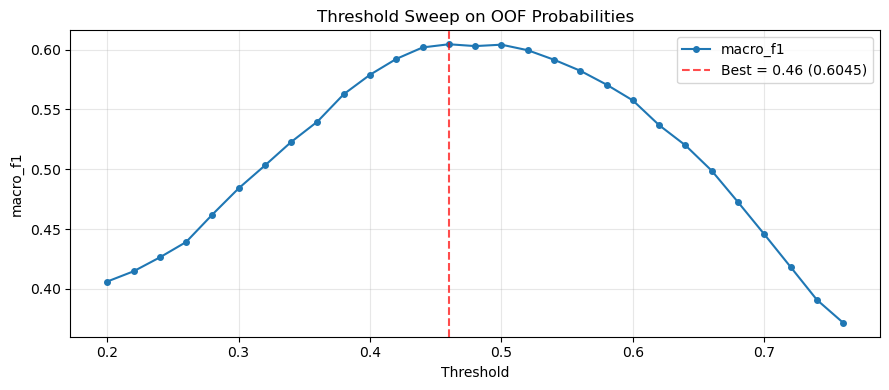

THRESHOLD updated: 0.50 → 0.46


In [17]:
if enable_threshold_tuning:
    _metric_fn = {
        'macro_f1':     lambda t, yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        'mcc':          lambda t, yt, yp: matthews_corrcoef(yt, yp),
        'balanced_acc': lambda t, yt, yp: balanced_accuracy_score(yt, yp),
    }[THRESHOLD_METRIC]

    threshold_grid   = np.arange(0.20, 0.76, 0.02)
    threshold_scores = {}
    for t in threshold_grid:
        preds = (oof_proba >= t).astype(int)
        threshold_scores[round(float(t), 2)] = _metric_fn(t, oof_true, preds)

    best_threshold = max(threshold_scores, key=threshold_scores.get)
    best_score     = threshold_scores[best_threshold]

    print(f'Best threshold: {best_threshold:.2f}  (OOF {THRESHOLD_METRIC}={best_score:.4f})')

    # Plot threshold sweep
    fig, ax = plt.subplots(figsize=(9, 4))
    ts = list(threshold_scores.keys())
    ss = list(threshold_scores.values())
    ax.plot(ts, ss, marker='o', markersize=4, linewidth=1.5, label=THRESHOLD_METRIC)
    ax.axvline(best_threshold, color='red', linestyle='--', alpha=0.7,
               label=f'Best = {best_threshold:.2f} ({best_score:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel(THRESHOLD_METRIC)
    ax.set_title('Threshold Sweep on OOF Probabilities')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if overwrite_threshold:
        print(f'THRESHOLD updated: {THRESHOLD:.2f} → {best_threshold:.2f}')
        THRESHOLD = best_threshold

## Final Model — Fit on Full Train/Val Set

The final model is trained on all 7,160 train/val rows using the aggregated HP. True-rate maps are computed on the full train/val set and saved — these are the maps used at submission time to look up test rows without seeing test labels.

In [18]:
print(f'[{_now()}] Fitting final model...')
_t0 = time()

_final_rate_maps: dict = {}
X_trainval_final = X_trainval.copy()
if enable_true_rate_features and _tr_group_cols:
    for _feat, _src_col in _tr_group_cols.items():
        _rate_map = _grp_trainval.groupby(_src_col)['_label'].mean()
        X_trainval_final[_feat] = _grp_trainval[_src_col].map(_rate_map).fillna(true_rate_fallback).values
        X_holdout[_feat]        = _grp_holdout[_src_col].map(_rate_map).fillna(true_rate_fallback).values
        _final_rate_maps[_feat] = _rate_map.to_dict()

_cat_indices_final = [X_trainval_final.columns.get_loc(c) for c in _cat_feature_names
                      if c in X_trainval_final.columns]

model = CatBoostClassifier(
    iterations=_best_params_final['iterations'],
    learning_rate=_best_params_final['learning_rate'],
    depth=_best_params_final['depth'],
    l2_leaf_reg=_best_params_final['l2_leaf_reg'],
    border_count=_best_params_final['border_count'],
    bagging_temperature=_best_params_final['bagging_temperature'],
    cat_features=_cat_indices_final,
    class_weights=CLASS_WEIGHTS,
    thread_count=-1,
    random_seed=42,
    verbose=0,
)
model.fit(X_trainval_final, y_trainval)
print(f'Done in {time()-_t0:.1f}s')

[22:13:44] Fitting final model...
Done in 4.9s


## Holdout Evaluation

The holdout set is touched for the first time here. All metrics are reported at the tuned threshold.

In [19]:
print(f'Using threshold: {THRESHOLD:.2f}\n')
y_proba = model.predict_proba(X_holdout)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

holdout_metrics = {
    'roc_auc':      roc_auc_score(y_holdout, y_proba),
    'pr_auc':       average_precision_score(y_holdout, y_proba),
    'macro_f1':     f1_score(y_holdout, y_pred, average='macro', zero_division=0),
    'f1_class1':    f1_score(y_holdout, y_pred, zero_division=0),
    'precision':    precision_score(y_holdout, y_pred, zero_division=0),
    'recall':       recall_score(y_holdout, y_pred, zero_division=0),
    'accuracy':     accuracy_score(y_holdout, y_pred),
    'mcc':          matthews_corrcoef(y_holdout, y_pred),
    'balanced_acc': balanced_accuracy_score(y_holdout, y_pred),
}
cm     = confusion_matrix(y_holdout, y_pred)

metrics_df = pd.DataFrame.from_dict(holdout_metrics, orient='index', columns=['value']).round(4)
display(metrics_df)
print()
print(classification_report(y_holdout, y_pred, target_names=['True (0)', 'False (1)']))

Using threshold: 0.46



,value
roc_auc,0.6756
pr_auc,0.7798
macro_f1,0.6219
f1_class1,0.7275
precision,0.7365
recall,0.7187
accuracy,0.6514
mcc,0.2441
balanced_acc,0.6232



              precision    recall  f1-score   support

    True (0)       0.51      0.53      0.52       631
   False (1)       0.74      0.72      0.73      1159

    accuracy                           0.65      1790
   macro avg       0.62      0.62      0.62      1790
weighted avg       0.66      0.65      0.65      1790



## Feature Importance

CatBoost's default importance is `PredictionValuesChange`: the average absolute change in the model's prediction when a feature is removed, evaluated over all training samples. This is equivalent to gain-based importance in LightGBM and is more interpretable than split count.

Look for:
- Whether the true-rate features (subject, party, job) dominate or share gain fairly with embeddings.
- With Option B (speaker true-rate dropped), the dominance ratio should be < 3× (vs LGBM's 6–8× with speaker true-rate included).

In [20]:
feature_names_final = X_trainval_final.columns.tolist()
importances = model.get_feature_importance()
importance_df = (
    pd.DataFrame({'feature': feature_names_final, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

TOP_N = 30
print(f'Top {TOP_N} features (PredictionValuesChange):')
display(importance_df.head(TOP_N))

Top 30 features (PredictionValuesChange):


,feature,importance
0,fe_speaker_job_true_rate,13.696183
1,fe_subject_true_rate,4.225488
2,speaker_grouped,3.798640
3,fe_party_true_rate,2.858258
4,statement_original_PERSON,2.089749
5,party_affiliation_grouped,1.941715
6,statement_original_vec_164,1.883838
7,statement_original_vec_105,1.609127
8,statement_original_vec_99,1.529060
9,fe_state_party,1.321672


## Evaluation Plots

Four panels:
1. **ROC curve** — overall ranking ability (threshold-independent)
2. **Precision-Recall curve** — useful for imbalanced datasets; PR-AUC is harder to game than ROC-AUC
3. **Confusion matrix** — per-cell counts at the tuned threshold
4. **Feature importance** — top 20 features by PredictionValuesChange

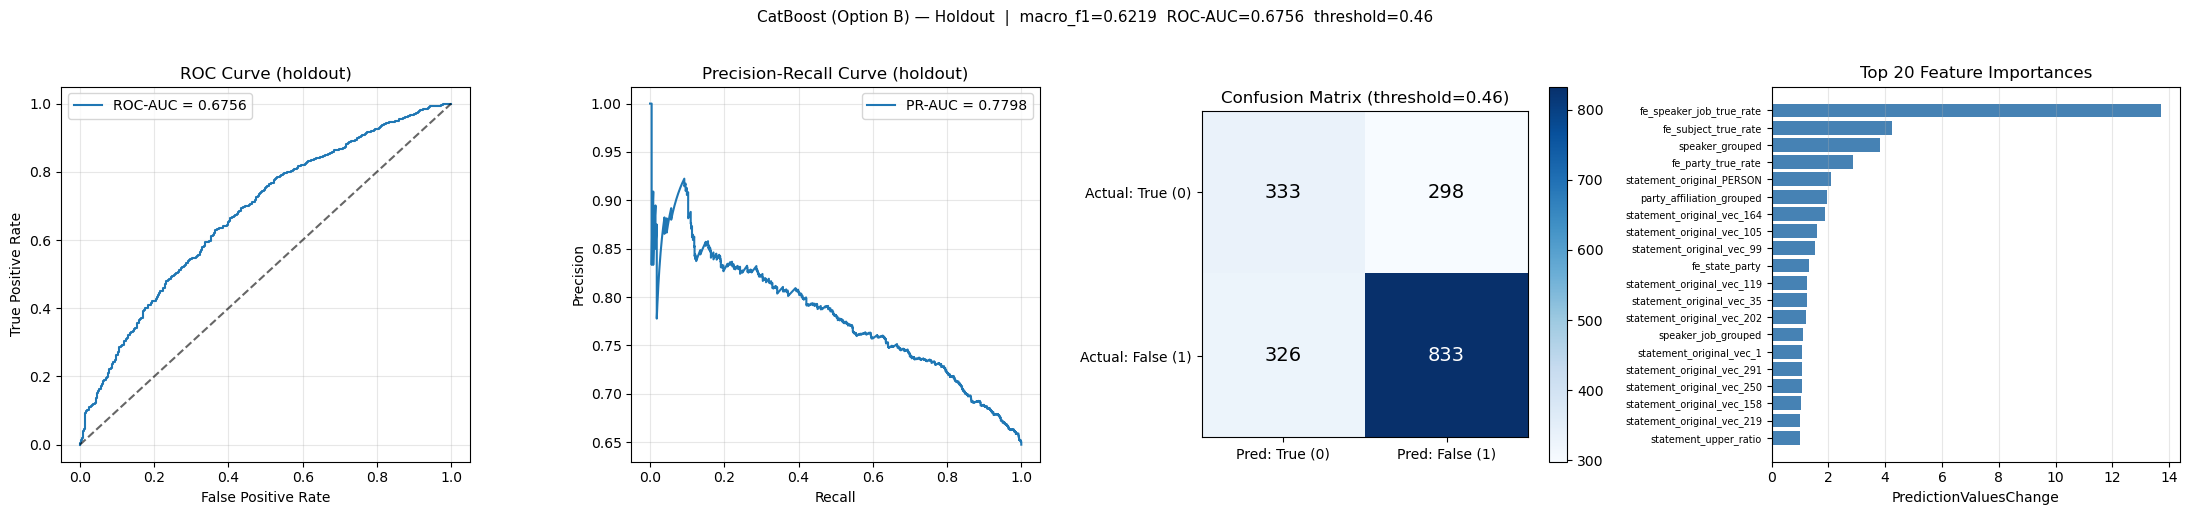

In [21]:
fpr, tpr, _      = roc_curve(y_holdout, y_proba)
prec_c, rec_c, _ = precision_recall_curve(y_holdout, y_proba)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# ROC
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {holdout_metrics['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[0].set_title('ROC Curve (holdout)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR
axes[1].plot(rec_c, prec_c, label=f"PR-AUC = {holdout_metrics['pr_auc']:.4f}")
axes[1].set_title('Precision-Recall Curve (holdout)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix
im = axes[2].imshow(cm, interpolation='nearest', cmap='Blues')
axes[2].set_title(f'Confusion Matrix (threshold={THRESHOLD:.2f})')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Pred: True (0)', 'Pred: False (1)'])
axes[2].set_yticklabels(['Actual: True (0)', 'Actual: False (1)'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
fig.colorbar(im, ax=axes[2])

# Feature importance
top20 = importance_df.head(20)
axes[3].barh(top20['feature'].values[::-1], top20['importance'].values[::-1], color='steelblue')
axes[3].set_title('Top 20 Feature Importances')
axes[3].set_xlabel('PredictionValuesChange')
axes[3].tick_params(axis='y', labelsize=7)
axes[3].grid(True, alpha=0.3, axis='x')

plt.suptitle(
    f'CatBoost (Option B) — Holdout  |  macro_f1={holdout_metrics["macro_f1"]:.4f}  '
    f'ROC-AUC={holdout_metrics["roc_auc"]:.4f}  threshold={THRESHOLD:.2f}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## Feature Importance — Full Bar Chart

Larger view of the top 30 features to inspect whether embedding dimensions appear alongside metadata features.

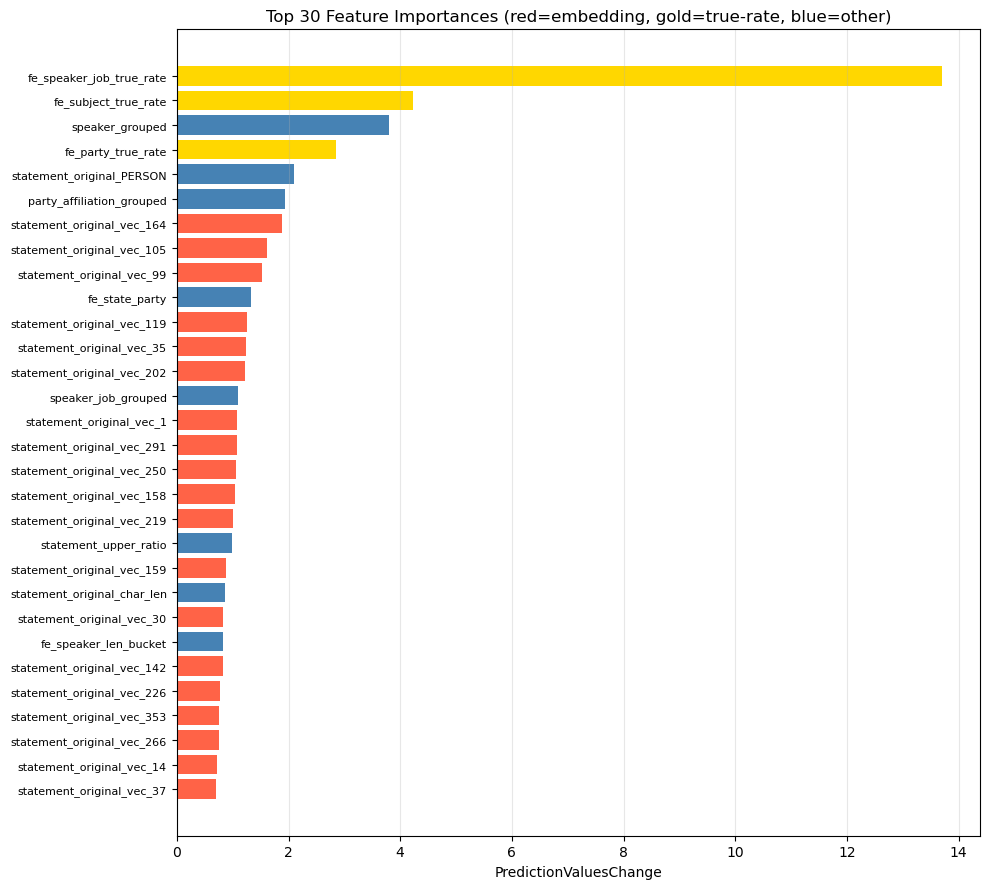

In [22]:
top30 = importance_df.head(30)
fig, ax = plt.subplots(figsize=(10, 9))
colors = ['tomato' if 'vec_' in f or f.startswith('vec_') else
          'gold' if '_true_rate' in f else 'steelblue'
          for f in top30['feature'].values[::-1]]
ax.barh(top30['feature'].values[::-1], top30['importance'].values[::-1], color=colors)
ax.set_title('Top 30 Feature Importances (red=embedding, gold=true-rate, blue=other)')
ax.set_xlabel('PredictionValuesChange')
ax.tick_params(axis='y', labelsize=8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Summary

| Metric | CV (OOF) | Holdout |
|---|---|---|
| Macro F1 | 0.6032 ± 0.0144 | 0.6219 |
| ROC-AUC | 0.6548 ± 0.0166 | 0.6756 |
| MCC | 0.2125 ± 0.0295 | 0.2441 |
| Balanced Accuracy | 0.6087 ± 0.0160 | 0.6232 |


**Key observations:**
- Class 0 (true statements) remains harder to predict than class 1 (false statements) — the imbalance and the nature of the task make false statements more consistently identifiable.
- The tuned threshold (below 0.5) improves recall on the minority class while keeping precision high for class 1.
